# 04-02 - Chips and Sixteen Numbers

The lecture said that a model does not read a scene. It reads chips, windows of a fixed size cut from the scene, also called tiles or patches, each with its own transform so that whatever the model says about a chip can be placed back on the ground. It said that Wednesday's chips are sixteen cells wide, which is 160 m of the town at the satellite's ten metres, that they overlap by half, and that each one is labelled by the class that covers most of it. A satellite scene has to be cut before a classifier can learn from it, and how it is cut, how wide, how far apart and by which rule for the label, decides what the classifier sees and what it never sees.

We take the scene and the labels of 04-01, cut one chip where the shops of Nassau Street meet the trees of the campus, and watch a single label describe half of it. Then we cut every chip in town at two strides, count them, count their labels, and meet the class imbalance the lecture warned about. We turn each chip into the sixteen numbers the lecture promised for Wednesday, the mean and the spread of each feature, and look at them for the purest chip of each class. We put the chips back on the map, draw the three kilometre blocks over them, and say why 04-03 will hold out whole blocks rather than random chips.

The ground truth file carries the numbers the lecture quoted, and every value we compute is printed beside its reference. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

reference = json.load(open("data/ground_truth.json"))["p04"]

## The scene and the labels, as 04-01 built them

04-01 read the scene of 22 August 2025, stacked its eight features, drew the town's boundary onto the grid and collapsed the WorldCover map to four classes. We need all of that again, so this cell repeats it line for line, as 04-01 did, and prints the one number that says the grid is the same:

In [2]:
with rasterio.open("data/s2_20250822_town_10m.tif") as f:
    blue, green, red, nir = (f.read(i).astype("float32") for i in (1, 2, 3, 4))
    transform, crs, shape = f.transform, f.crs, (f.height, f.width)
with rasterio.open("data/s2_20250822_town_20m.tif") as f:
    up = lambda a: np.repeat(np.repeat(a, 2, axis=0), 2, axis=1)       # a cell of 20 m becomes 2 by 2 cells of 10 m
    swir16, swir22 = up(f.read(1).astype("float32")), up(f.read(2).astype("float32"))

FEATURES = ["blue", "green", "red", "nir", "swir16", "swir22", "ndvi", "ndbi"]
with np.errstate(invalid="ignore", divide="ignore"):
    ndvi = (nir - red) / (nir + red)
    ndbi = (swir16 - nir) / (swir16 + nir)
feat = np.stack([blue, green, red, nir, swir16, swir22, ndvi, ndbi])
feat[:, (red <= 0) | (nir <= 0)] = np.nan                                # no reflectance, no feature

town = gpd.read_file("data/princeton_boundary.geojson").to_crs(crs)
mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=shape, transform=transform, fill=0, dtype="uint8").astype(bool)

CLASSES = {1: "tree cover", 2: "grass", 3: "built-up", 4: "water"}
COLOURS = {1: "#2f7d32", 2: "#a8d05f", 3: "#b0413e", 4: "#3b6fb6"}
COLLAPSE = {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4}                   # WorldCover's codes to the four classes
with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    raw = f.read(1)
lab = np.zeros(raw.shape, dtype="uint8")
for wc_code, cls in COLLAPSE.items():
    lab[raw == wc_code] = cls
lab[~mask] = 0                                                           # 0 outside the town, and where the map's class is none of the four

rgb = np.stack([red, green, blue], axis=-1)                              # true colour for the pictures, stretched to the town's 98th percentile
rgb = np.clip(rgb / np.nanpercentile(rgb[mask], 98), 0, 1)
rgb[~mask] = 1.0
print(f"cells in town {int(mask.sum()):,}   reference {reference['scene']['cells_in_town']:,}")

cells in town 476,595   reference 476,595


## One chip

A chip is a window. Its position is a row and a column on the grid, its size is a number of cells, and the six numbers of its transform are the scene's with the origin moved to its corner. We take a square of the stride grid on the north edge of the campus, where the shops of Nassau Street meet the trees behind Nassau Hall, show it on the true colour scene, look at the labels of its cells, and let the majority rule decide its label:

tree cover  114 cells
grass         0 cells
built-up    142 cells
water         0 cells
majority built-up, which describes 55.5% of the chip's labelled cells
its own transform puts its top left corner at (528820, 4466700) in EPSG:32618, 10 m a cell
the window eight cells further south: majority tree cover with 72.3%


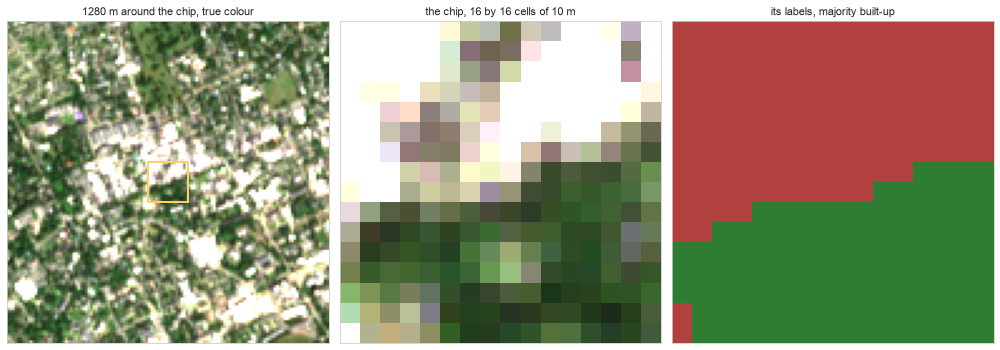

In [3]:
r0, c0, size = 472, 544, 16               # a square of the stride grid where Nassau Street meets the campus; change it and see
chip_lab = lab[r0:r0 + size, c0:c0 + size]
counts = np.bincount(chip_lab[chip_lab > 0], minlength=5)[1:]           # cells of tree cover, grass, built-up, water
majority = int(np.argmax(counts)) + 1
for cls, n in zip(CLASSES, counts):
    print(f"{CLASSES[cls]:11} {n:3d} cells")
print(f"majority {CLASSES[majority]}, which describes {counts.max() / counts.sum():.1%} of the chip's labelled cells")
chip_transform = transform * rasterio.Affine.translation(c0, r0)         # the chip's own transform, the scene's moved to its corner
print(f"its own transform puts its top left corner at ({chip_transform.c:.0f}, {chip_transform.f:.0f}) in {crs}, {chip_transform.a:.0f} m a cell")
south = lab[r0 + 8:r0 + 8 + size, c0:c0 + size]                        # the same window, eight cells further south
counts_south = np.bincount(south[south > 0], minlength=5)[1:]
print(f"the window eight cells further south: majority {CLASSES[int(np.argmax(counts_south)) + 1]} with {counts_south.max() / counts_south.sum():.1%}")

class_cmap = ListedColormap(["white"] + [COLOURS[c] for c in CLASSES])
pad = 56
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(rgb[r0 - pad:r0 + size + pad, c0 - pad:c0 + size + pad])
axes[0].add_patch(Rectangle((pad - 0.5, pad - 0.5), size, size, fill=False, edgecolor="#ffd166", linewidth=2))
axes[0].set_title(f"{(2 * pad + size) * 10} m around the chip, true colour", fontsize=11)
axes[1].imshow(rgb[r0:r0 + size, c0:c0 + size], interpolation="nearest")
axes[1].set_title(f"the chip, {size} by {size} cells of 10 m", fontsize=11)
axes[2].imshow(chip_lab, cmap=class_cmap, vmin=0, vmax=4, interpolation="nearest")
axes[2].set_title(f"its labels, majority {CLASSES[majority]}", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Read the counts and the three panels together. The upper half of the chip is the town centre and the lower half the campus canopy; the map calls a little over half of its cells built-up and every other cell tree cover, and the majority rule hands the whole chip the label built-up. That label is not wrong, and it is not a truth either. It describes half of the chip and denies the other half, exactly as the lecture's chips A and B did on the annotation frame, where the room split on the same pictures the map split on. The last printed line makes the point the lecture made in words. Slide the window eight cells south and the same street, the same trees, get the label tree cover. Every chip of a training set that straddles a boundary carries a label like this one, and a classifier trained on it is taught that a picture of shops and trees means shops.

The line about the corner is the chip's own transform at work. The chip is a row and a column on the scene's grid, and the scene's six numbers, moved to the chip's corner, turn that back into metres on the ground. That is why anything a model says about a chip can be drawn on a map, and it is how the last section of this notebook puts every chip back where it came from.

## Every chip, half overlapping

Now every chip. The function below walks the grid sixteen cells at a time with a step of eight, rows first and then columns, and keeps a window when at least nine tenths of its cells carry one of the four labels and every feature in it is a finite number. For each chip it records the row and the column of its corner, its majority class, the share of the labelled cells that majority holds, and then the mean and the standard deviation of each of the eight features, which are the sixteen numbers of the next section. It is the same code 04-03 uses and the pipeline that wrote the ground truth file ran, so the counts have to match:

In [4]:
def chip_table(feat, lab, size=16, stride=8):
    '''One row per chip, holding its row, its column, its majority class, that majority's share, then the mean and the
    spread of the eight features. A chip is kept when at least 90 percent of its cells are labelled and every feature is finite.'''
    rows, cols = lab.shape
    recs = []
    for r0 in range(0, rows - size + 1, stride):
        for c0 in range(0, cols - size + 1, stride):
            l = lab[r0:r0 + size, c0:c0 + size]
            f = feat[:, r0:r0 + size, c0:c0 + size].reshape(len(feat), -1)
            if np.mean(l > 0) < 0.9 or not np.isfinite(f).all():
                continue
            counts = np.bincount(l[l > 0], minlength=5)[1:]
            majority = int(np.argmax(counts)) + 1
            recs.append((r0, c0, majority, counts.max() / counts.sum(), *f.mean(axis=1), *f.std(axis=1)))
    return np.array(recs)


def describe(table, ref):
    '''Print the size of a chip table, its class counts and the three summaries, each beside its reference.'''
    label, share = table[:, 2].astype(int), table[:, 3]
    print(f"chips kept {len(table):,}   reference {ref['n']:,}")
    for cls, name in CLASSES.items():
        print(f"  {name:11} {int(np.sum(label == cls)):5,}   reference {ref['class_counts'][name]:,}")
    top = int(np.bincount(label).argmax())
    print(f"the commonest label, {CLASSES[top]}, is the label of {100 * np.mean(label == top):.1f} percent of the chips   reference {ref['majority_class_percent']}")
    print(f"the majority describes {100 * share.mean():.1f} percent of a chip on average   reference {ref['share_mean_percent']}")
    print(f"mixed chips, where the majority is below 60 percent, are {100 * np.mean(share < 0.6):.1f} percent   reference {ref['mixed_percent']}")

positions = len(range(0, lab.shape[0] - 16 + 1, 8)) * len(range(0, lab.shape[1] - 16 + 1, 8))
over = chip_table(feat, lab, size=16, stride=8)
print(f"windows on the grid {positions:,}, of {reference['chips']['size_cells']} cells every {reference['chips']['stride_cells']}")
describe(over, reference["chips"]["overlapping"])

windows on the grid 14,145, of 16 cells every 8
chips kept 7,166   reference 7,166
  tree cover  6,136   reference 6,136
  grass         645   reference 645
  built-up      318   reference 318
  water          67   reference 67
the commonest label, tree cover, is the label of 85.6 percent of the chips   reference 85.6
the majority describes 87.0 percent of a chip on average   reference 87.0
mixed chips, where the majority is below 60 percent, are 10.0 percent   reference 10.0


The first line says how many windows the grid offered and the second how many survived; the raster is the town's bounding box, so about half the windows fall outside the boundary or straddle it and fail the nine tenths rule. Look at the four class counts. The town is four fifths tree cover by cells, and the chips are more so, because a chip takes its majority and a majority favours whatever is common. Roughly six of every seven chips are labelled tree cover, and that share is a number to remember. It is the score of a classifier that says tree cover for every chip without looking at a single feature, the majority baseline of the lecture, and it is the number the forest of 04-03 has to beat before it can claim to have learned anything. The last two lines say how clean the labels are. On average the majority holds a little under nine tenths of a chip, and one chip in ten is mixed, with a majority below sixty percent, like the chip on Nassau Street.

This is class imbalance, and it does two things to a classifier. The first is that the rare classes are rare in training too. A forest sees a few hundred chips of built-up and a few dozen of water against thousands of tree cover, and every doubt it has is settled in favour of trees. The second is that the overall accuracy hides it. A model that never finds a single water chip loses less than one point in a hundred for the omission. The remedies are the ones the lecture named, an error matrix read class by class rather than one overall number, and a training sample that is stratified, drawn in fixed shares from every class. 04-03 does the first, and asks you about the second.

## Sixteen numbers per chip

A forest cannot read a picture. It reads a list of numbers, one list per example, and somebody has to decide what the numbers are. The lecture's hand-crafted route named twelve for a NAIP chip, and for ours it named sixteen, the mean of each of the eight features, which is the chip's tone, and the standard deviation of each, which is its texture, the first two of Lecture 03's eight elements of image interpretation written as numbers. The table already holds them, four columns of bookkeeping and then the sixteen, and the ground truth file names them in the same order:

In [5]:
names = [f"mean {name}" for name in FEATURES] + [f"spread {name}" for name in FEATURES]
print("the sixteen numbers  ", ", ".join(names))
print("as the reference names them, in the same order:", names == reference["chips"]["names"])
chips = pd.DataFrame(over[:, 4:], columns=names)
chips.insert(0, "share", over[:, 3])
chips.insert(0, "label", [CLASSES[c] for c in over[:, 2].astype(int)])
chips.insert(0, "col", over[:, 1].astype(int))
chips.insert(0, "row", over[:, 0].astype(int))
print(f"{len(chips):,} rows, {chips.shape[1] - 4} numbers each")
chips.head(8).round(3)

the sixteen numbers   mean blue, mean green, mean red, mean nir, mean swir16, mean swir22, mean ndvi, mean ndbi, spread blue, spread green, spread red, spread nir, spread swir16, spread swir22, spread ndvi, spread ndbi
as the reference names them, in the same order: True
7,166 rows, 16 numbers each


,row,col,label,share,mean blue,mean green,mean red,mean nir,mean swir16,mean swir22,mean ndvi,mean ndbi,spread blue,spread green,spread red,spread nir,spread swir16,spread swir22,spread ndvi,spread ndbi
0,24,584,built-up,0.724,0.078,0.094,0.090,0.216,0.174,0.114,0.444,-0.087,0.083,0.084,0.088,0.083,0.042,0.043,0.288,0.167
1,24,592,tree cover,0.586,0.061,0.078,0.069,0.246,0.171,0.095,0.611,-0.160,0.092,0.092,0.098,0.084,0.045,0.040,0.318,0.167
2,24,600,tree cover,0.902,0.033,0.051,0.035,0.275,0.161,0.075,0.803,-0.254,0.062,0.060,0.065,0.060,0.033,0.026,0.197,0.102
3,24,608,tree cover,0.984,0.025,0.045,0.028,0.268,0.154,0.073,0.798,-0.258,0.010,0.011,0.014,0.062,0.018,0.011,0.124,0.094
4,32,560,built-up,0.627,0.063,0.080,0.076,0.210,0.169,0.111,0.442,-0.083,0.032,0.029,0.034,0.072,0.029,0.022,0.257,0.135
5,32,568,built-up,0.908,0.108,0.122,0.124,0.196,0.175,0.120,0.267,-0.027,0.112,0.114,0.118,0.113,0.069,0.033,0.182,0.117
6,32,576,built-up,0.781,0.106,0.120,0.118,0.228,0.178,0.112,0.385,-0.095,0.122,0.125,0.130,0.119,0.071,0.044,0.262,0.153
7,32,584,tree cover,0.582,0.051,0.067,0.058,0.239,0.157,0.090,0.615,-0.183,0.056,0.056,0.058,0.077,0.029,0.031,0.247,0.137


Every row is one chip and every column after the first four is one of the sixteen numbers, so the whole training set of 04-03 is this table, some seven thousand rows by sixteen. Here are the sixteen for the purest chip of each class, chosen as the chip whose majority holds the largest share, with the chip in true colour above its bars, in the manner of the lecture's frame on hand-crafted features. Under the figure we print the sixteen numbers of each chip, the map's own codes for its cells, and the similarity between the four lists, the score of the lecture that reads one when two lists point the same way:

tree cover  row  32, col 632, the map's own codes tree cover 256
            means   blue 0.02  green 0.04  red 0.02  nir 0.30  swir16 0.15  swir22 0.06  ndvi 0.89  ndbi -0.34
            spreads blue 0.00  green 0.01  red 0.00  nir 0.05  swir16 0.02  swir22 0.01  ndvi 0.03  ndbi 0.06
grass       row 352, col 368, the map's own codes grassland 248, cropland 8
            means   blue 0.06  green 0.09  red 0.10  nir 0.31  swir16 0.33  swir22 0.20  ndvi 0.49  ndbi 0.04
            spreads blue 0.01  green 0.01  red 0.03  nir 0.06  swir16 0.04  swir22 0.04  ndvi 0.14  ndbi 0.14
built-up    row 456, col 544, the map's own codes tree cover 2, built-up 253, bare or sparse vegetation 1
            means   blue 0.13  green 0.14  red 0.15  nir 0.19  swir16 0.18  swir22 0.14  ndvi 0.15  ndbi -0.01
            spreads blue 0.08  green 0.08  red 0.08  nir 0.08  swir16 0.05  swir22 0.04  ndvi 0.15  ndbi 0.12
water       row 560, col 656, the map's own codes tree cover 9, permanent water bodies 247


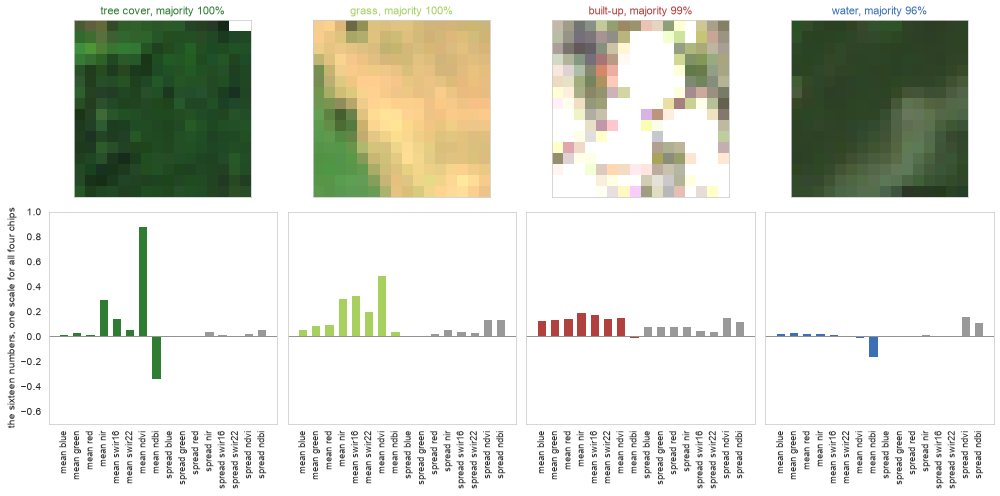

In [6]:
purest = {}
for cls in CLASSES:
    rows_of = np.flatnonzero(over[:, 2] == cls)
    purest[cls] = int(rows_of[np.argmax(over[rows_of, 3])])

fig, axes = plt.subplots(2, 4, figsize=(14, 7), gridspec_kw={"height_ratios": [1, 1.2]})
for k, (cls, i) in enumerate(purest.items()):
    r, c = int(over[i, 0]), int(over[i, 1])
    axes[0, k].imshow(rgb[r:r + 16, c:c + 16], interpolation="nearest")
    axes[0, k].set_title(f"{CLASSES[cls]}, majority {over[i, 3]:.0%}", fontsize=11, color=COLOURS[cls])
    axes[0, k].set_xticks([]); axes[0, k].set_yticks([])
    axes[1, k].bar(range(16), over[i, 4:], color=[COLOURS[cls]] * 8 + ["0.6"] * 8, width=0.7)
    axes[1, k].axhline(0, color="0.3", linewidth=0.6)
    axes[1, k].set_xticks(range(16)); axes[1, k].set_xticklabels(names, rotation=90, fontsize=9)
    axes[1, k].set_ylim(-0.7, 1.0); axes[1, k].grid(False)
    if k:
        axes[1, k].set_yticklabels([])
axes[1, 0].set_ylabel("the sixteen numbers, one scale for all four chips")
fig.tight_layout()

with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    wc_names = json.loads(f.tags()["classes"])                          # the map's own names for its codes, from the file's tags
for cls, i in purest.items():
    r, c = int(over[i, 0]), int(over[i, 1])
    codes, n_cells = np.unique(raw[r:r + 16, c:c + 16], return_counts=True)
    print(f"{CLASSES[cls]:11} row {r:3d}, col {c:3d}, the map's own codes " + ", ".join(f"{wc_names[str(k)]} {m}" for k, m in zip(codes, n_cells)))
    print(f"{'':11} means   " + "  ".join(f"{name.split()[1]} {v:.2f}" for name, v in zip(names[:8], over[i, 4:12])))
    print(f"{'':11} spreads " + "  ".join(f"{name.split()[1]} {v:.2f}" for name, v in zip(names[8:], over[i, 12:])))
vectors = over[list(purest.values()), 4:]
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
similarity = unit @ unit.T                                               # 1 means two lists point the same way, as on the lecture's frame
pairs = [(a, b) for a in range(4) for b in range(a + 1, 4)]
print("similarity  " + ", ".join(f"{CLASSES[list(purest)[a]]} to {CLASSES[list(purest)[b]]} {similarity[a, b]:.2f}" for a, b in pairs))

Water is unmistakable, low and flat in every band, with a vegetation index at zero, because a lake reflects almost nothing in the near infrared. Its two widest bars are the spreads of the two indices, and that is not the lake varying. An index is a ratio of two small numbers over water, and 03-02 saw the same thing at Lake Carnegie through the year; a spread can measure noise as easily as texture. The tree chip is the woods as the lecture drew them, dark in red, bright in near infrared, a vegetation index near the top of its range, and spreads so small that the bars barely show, because a closed canopy at ten metres is the most uniform ground in town. The built-up chip is the brightest in the three visible bands and nearly flat across the spectrum, a grey of roofs and asphalt, and the spreads of its bands are the widest of the four, because a town centre at ten metres is roofs, streets and trees mixed.

The grass chip is the surprise, and the printed codes say why. The map's own class for its cells is grassland, and in late August it is a tan field, brighter than the trees in red and in both shortwave infrared bands, with a vegetation index near half. The similarities put its list nearer the built-up chip's than the tree chip's. Remember what our label hides. Grass is a collapse of grassland, cropland and wetland, so a dry hayfield and a watered lawn carry the same label, and a lawn's sixteen numbers would sit much nearer the trees', which is what the lecture's twelve numbers found for a NAIP chip, a similarity of 0.99 between trees and grass. Named numbers see only what a person named, and nobody here named the height of a canopy, the roughness of a crown or the date of the last mowing. The forest of 04-03 will lean on the shortwave infrared, which the water in a leaf affects, and grass against trees is still where it will err most.

There is a second route to numbers, which the lecture showed on the same frame. A pretrained network turns a chip into five hundred and twelve numbers it learned to compute on millions of ordinary photographs, and nobody named any of them. 04-03 asks such a network for those numbers in an optional cell, where the deep learning library exists, and trains a second forest on them for comparison. Today the numbers are ours, and we can say what every one of them means.

## Edge to edge

The stride is a decision, and the lecture's table of strides had the arithmetic. With a step equal to the chip's width the chips touch without overlapping, the tiling of a floor, and the same function with a stride of sixteen gives that table:

In [7]:
tiled = chip_table(feat, lab, size=16, stride=16)
describe(tiled, reference["chips"]["tiled"])
print(f"stride 8 gives {len(over) / len(tiled):.2f} times the chips of stride 16, from the same {int(mask.sum()):,} cells")
print(f"a cell inside the town lies in {(16 // 8) ** 2} chips at stride 8 and in {(16 // 16) ** 2} at stride 16")

chips kept 1,791   reference 1,791
  tree cover  1,531   reference 1,531
  grass         157   reference 157
  built-up       88   reference 88
  water          15   reference 15
the commonest label, tree cover, is the label of 85.5 percent of the chips   reference 85.5
the majority describes 87.1 percent of a chip on average   reference 87.1
mixed chips, where the majority is below 60 percent, are 9.4 percent   reference 9.4
stride 8 gives 4.00 times the chips of stride 16, from the same 476,595 cells
a cell inside the town lies in 4 chips at stride 8 and in 1 at stride 16


Halving the stride roughly quadruples the chips, because a step of eight in each of two directions places four corners where a step of sixteen placed one, and the printed ratio is four as near as makes no difference, since the nine tenths rule and the edge of the town cut the two grids in the same proportion. Nothing else changed. The class counts are in the same proportions, the majority baseline is the same to within a tenth of a point, and the mean share of the majority is the same, because the tiled chips are the overlapping ones taken at every second row and every second column. What changed is what the chips share. At stride eight every cell in the interior of the town lies in four chips, a chip shares half its cells with each of its four nearest neighbours and a quarter with each diagonal one, and two chips that share half their cells have nearly the same sixteen numbers. Put one of them in the training set and the other in the test set, and the test asks the forest about ground it has already seen. That is the leak the lecture put a pin in, and 04-03 measures it, with a random split of the overlapping chips against a split by blocks.

## Where the chips are, and the blocks

A chip is a row and a column, and a transform turns the two into a coordinate on the ground. The centre of each chip in the table is eight cells in from its corner, and the scene's transform puts it on the map. With the centres on the map we can draw the town's boundary through them and lay a grid of three kilometre blocks over them, hung on the lowest and leftmost centre so that every chip has a block:

blocks of 3000 m that hold chips 10   reference 10
column  row
0       0       239
        1       806
        2       915
1       0       778
        1      1367
        2      1303
        3        35
2       1       606
        2      1098
        3        19


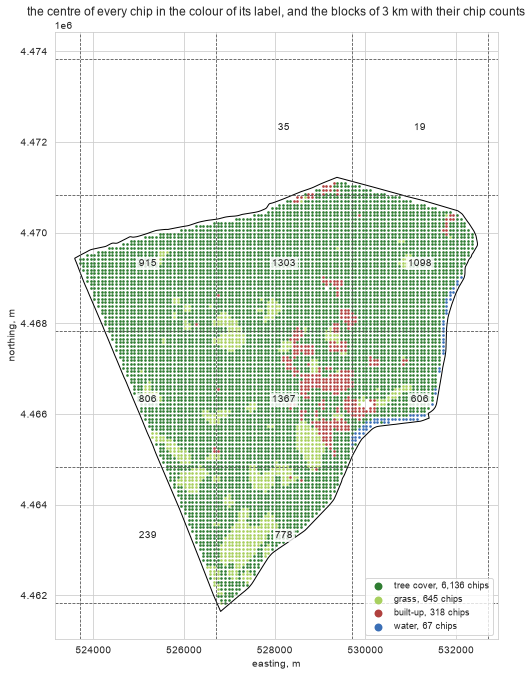

In [8]:
xs, ys = transform * (over[:, 1] + 8, over[:, 0] + 8)                   # the centre of every chip, from column and row to the ground
xs, ys = np.asarray(xs), np.asarray(ys)
BLOCK = 3000
block = ((xs - xs.min()) // BLOCK).astype(int) * 1000 + ((ys - ys.min()) // BLOCK).astype(int)
print(f"blocks of {BLOCK} m that hold chips {len(np.unique(block))}   reference {reference['forest']['blocks_n']}")
per_block = pd.DataFrame({"column": block // 1000, "row": block % 1000}).value_counts().sort_index()
print(per_block.rename("chips").to_string())

fig, ax = plt.subplots(figsize=(9, 9.5))
for cls, name in CLASSES.items():
    sel = over[:, 2] == cls
    ax.scatter(xs[sel], ys[sel], s=7, color=COLOURS[cls], linewidths=0, label=f"{name}, {int(sel.sum()):,} chips")
town.boundary.plot(ax=ax, color="black", linewidth=1)
for x in np.arange(xs.min(), xs.max() + BLOCK, BLOCK):
    ax.axvline(x, color="0.3", linewidth=0.8, linestyle="--")
for y in np.arange(ys.min(), ys.max() + BLOCK, BLOCK):
    ax.axhline(y, color="0.3", linewidth=0.8, linestyle="--")
for (column, row), n in per_block.items():
    ax.text(xs.min() + (column + 0.5) * BLOCK, ys.min() + (row + 0.5) * BLOCK, f"{n}", ha="center", va="center", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2))
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=9, markerscale=3)
ax.set_title("the centre of every chip in the colour of its label, and the blocks of 3 km with their chip counts", fontsize=12)
ax.set_xlabel("easting, m"); ax.set_ylabel("northing, m")
fig.tight_layout()

The map is the town as the forest will meet it, one dot per chip in the colour of its label. The dots come in patches, the woods solid green, the centre of town red, the lake a blue edge, and that is the point. Neighbouring chips look alike, in their labels and in their sixteen numbers, because the ground is continuous and the chips overlap besides. Lecture 02 measured how far that likeness reaches with a semivariogram and found about three kilometres, and it showed that a random split puts four neighbouring pairs in five on opposite sides of the line, against one in nine for blocks of three kilometres. Lecture 04's spatial cross-validation is the answer, and the dashed grid is its unit. 04-03 will hold out whole blocks, train on the chips of the others, and score the forest on ground it has never seen. The printed counts already say that the folds will not be equal, because the town is not square, and that the fullest block is the one that holds the town centre.

## Your turn

Cut the town into chips twice as wide, thirty two cells or 320 m, at a stride of sixteen, so that they overlap by half as the chips above do. Before you run it, write down three guesses. Will there be more chips or fewer than in the tiled table, and why is the answer not obvious? Will a larger share of them be tree cover? And will the majority hold a larger or a smaller share of a chip on average? Then compute the three numbers and write one sentence on what the width of a chip does to its label.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. chip_table takes the features, the labels, a size and a stride, all in cells, and column 2 of its table is the label, column 3 the majority's share.
#
# big = chip_table(feat, lab, size=___, stride=___)
# label = big[:, 2].astype(int)
# print(f"{len(big):,} chips of 32 cells every 16, {np.mean(label == ___):.1%} of them tree cover, majority share {big[:, 3].mean():.1%} on average")

## Check your understanding

1. The chip on Nassau Street was labelled by a slim majority, and the same window eight cells south got the other label. What does that say about a label as a truth, and what would you tell an annotator who has to give such a chip one class?
2. A classifier that answers tree cover for every chip scores the majority baseline on the overlapping table. Why is the baseline nearly the same on the tiled table, and what would have to change on the ground for it to fall?
3. Two chips side by side at stride eight share how many of their 256 cells, and two diagonal neighbours how many? Explain in one sentence what happens to a test score when one chip of such a pair is in the training set and the other in the test set.
4. The purest grass chip in town is a dry field whose sixteen numbers sit nearer the town centre's than the woods'. What does that say about the label grass as we collapsed it, and name one thing about a canopy that no number computed from a 10 m scene can carry.

## Where we are

You can cut a scene into chips of a given size and stride, label each one by the majority of the cells under it, and say what that label describes and what it denies. You know how many chips the town gives at two strides and why halving the stride quadruples them, you have seen the class imbalance in the counts and know the score it hands a classifier that never looks, and you know that overlapping chips share their cells and why that matters for a test. You can turn a chip into sixteen numbers a person named, read them for four kinds of ground, and place a chip back on the map, where the blocks of 04-03 are waiting.

The habit worth keeping: before you train anything, print the class counts of your chips and the score the commonest class would get without looking, and keep that number beside every accuracy you report.

In 04-03 we train the forest on these sixteen numbers, hold out whole blocks, and read its error matrix against the baseline of today.

## Further resources

Nothing in this course requires anything below.

Chapter 6 of Wu, GeoAI with Python, on the course reading list, is the training data pipeline, with the tiling of a scene into chips and the table of strides that the lecture drew from: https://book.opengeoai.org

Stewart and colleagues, TorchGeo: Deep Learning with Geospatial Data (2022), describes the library that cuts chips from rasters with their transforms and samples them at random or on a grid: https://doi.org/10.1145/3557915.3560953

The Sentinel-2 files in this folder contain modified Copernicus Sentinel data 2025. The land cover map is ESA WorldCover 2021 v200 (Zanaga et al. 2022, CC BY 4.0). The municipal boundary is a public record of NJGIN.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The chips of thirty two cells at a stride of sixteen, computed from the files themselves so that the cell stands on its own:

```python
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize

with rasterio.open("data/s2_20250822_town_10m.tif") as f:
    blue, green, red, nir = (f.read(i).astype("float32") for i in (1, 2, 3, 4))
    transform, crs, shape = f.transform, f.crs, (f.height, f.width)
with rasterio.open("data/s2_20250822_town_20m.tif") as f:
    up = lambda a: np.repeat(np.repeat(a, 2, axis=0), 2, axis=1)
    swir16, swir22 = up(f.read(1).astype("float32")), up(f.read(2).astype("float32"))
with np.errstate(invalid="ignore", divide="ignore"):
    feat = np.stack([blue, green, red, nir, swir16, swir22, (nir - red) / (nir + red), (swir16 - nir) / (swir16 + nir)])
feat[:, (red <= 0) | (nir <= 0)] = np.nan
town = gpd.read_file("data/princeton_boundary.geojson").to_crs(crs)
mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=shape, transform=transform, fill=0, dtype="uint8").astype(bool)
with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    raw = f.read(1)
lab = np.zeros(raw.shape, dtype="uint8")
for wc_code, cls in {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4}.items():
    lab[raw == wc_code] = cls
lab[~mask] = 0

size, stride = 32, 16
rows, cols = lab.shape
recs = []
for r0 in range(0, rows - size + 1, stride):
    for c0 in range(0, cols - size + 1, stride):
        l = lab[r0:r0 + size, c0:c0 + size]
        f = feat[:, r0:r0 + size, c0:c0 + size].reshape(len(feat), -1)
        if np.mean(l > 0) < 0.9 or not np.isfinite(f).all():
            continue
        counts = np.bincount(l[l > 0], minlength=5)[1:]
        recs.append((r0, c0, int(np.argmax(counts)) + 1, counts.max() / counts.sum(), *f.mean(axis=1), *f.std(axis=1)))
big = np.array(recs)
label = big[:, 2].astype(int)
print(f"{len(big):,} chips of {size} cells every {stride}, {np.mean(label == 1):.1%} of them tree cover, majority share {big[:, 3].mean():.1%} on average")
```

The count lands close to the tiled table's rather than the overlapping one's, because the number of chips is set by the stride and not by the width, and the stride of sixteen is the same in both; the wider window loses a few more chips at the edge of the town, where it fails the nine tenths rule more often. A larger share of them is tree cover, because a bigger window is more often dominated by the common class, and the small patches of grass or built-up that ruled a chip of sixteen are outvoted in a chip of thirty two. And the majority holds a smaller share of a chip on average, because a wider window straddles more boundaries. Width trades detail for context. A wider chip carries more of its neighbourhood into its sixteen numbers and gets a coarser label for it, and no width is right for every question, which is why the lecture called the size of a chip a decision.